# Figure generation

This notebook extends `energy_sustainability_ml.ipynb`, part of my final-year
Bachelor's thesis in Mechanical Engineering. It builds the figures used in the repository README and in the
`images/` folder. Without repeating the analysis, it reloads the data, reuses the same cleaning and models, and exports the plots with a single, consistent style.

*Español:* Este notebook extiende `energy_sustainability_ml.ipynb`, parte de mi Trabajo de Fin de Grado en Ingeniería Mecánica. Genera las figuras del README y de la carpeta `images/` sin repetir el análisis: primero carga los datos, reutiliza la misma limpieza y modelos, y finalmente
se exporta las gráficas con un estilo uniforme.

## How it works

The notebook only needs the dataset CSV. From there:

1. Load and clean the data with the same steps as the analysis notebook.
2. Build the EDA figures straight from the clean dataframe (distributions,
   boxplots, correlation matrix, temporal trends).
3. Train the models and build the results figures from them (model comparison,
   feature importance, actual vs. predicted).

The visual style is set once in the first code cell, so every figure shares the
same colors, font and grid.

## 1. Setup

In [1]:
# Figure generation for the repository.
# Extends the analysis notebook: it reloads the dataset, reuses the same cleaning
# and models, and saves the plots to the images/ folder with a consistent style.

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Visual style. Defining it once here keeps every figure consistent (same colors,
# font and grid), which is what makes the gallery look uniform on GitHub.
INK = "#1b2733"
MUTED = "#5b6b7b"
GRID = "#e3e8ee"

# One color per concept, reused across all figures.
C_CO2 = "#e4572e"       # emissions
C_ENERGY = "#2a9d8f"    # energy
C_GDP = "#4361ee"       # economy
C_RENEW = "#2a9d8f"     # renewables
MODEL_COLORS = {
    "Linear Regression": "#4361ee",
    "Ridge Regression":  "#3a86ff",
    "Random Forest":     "#2a9d8f",
}

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.titlecolor": INK,
    "axes.labelsize": 12.5,
    "axes.labelcolor": INK,
    "axes.labelweight": "medium",
    "axes.edgecolor": "#c7d0da",
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": GRID,
    "grid.linewidth": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
    "legend.fontsize": 11,
})

IMAGES_DIR = "images"


def _thousands(x, _pos):
    # Shorten axis numbers with k / M suffixes so they stay readable.
    if abs(x) >= 1e9:
        return f"{x/1e9:.1f}B"
    if abs(x) >= 1e6:
        return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"{x/1e3:.0f}k"
    return f"{x:.0f}"


def save(fig, name):
    path = os.path.join(IMAGES_DIR, name)
    fig.savefig(path)
    plt.show()
    print("  saved:", path)


def bar_labels(ax, bars, values, fmt="{:.3f}", pad=3, color=INK):
    for b, v in zip(bars, values):
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", xytext=(0, pad),
                    textcoords="offset points", fontsize=10.5,
                    fontweight="bold", color=color)


def load_and_clean(path):
    # Same cleaning as the analysis notebook. The only addition is auto-detecting
    # the separator, so the script works whether the CSV uses commas or semicolons.
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()
    if "Density (P/Km2)" in df.columns:
        df.rename(columns={"Density (P/Km2)": "Density"}, inplace=True)

    # A semicolon export usually comes with comma decimals (European format).
    # Turn every non-country column into a real number regardless of the format.
    for col in df.columns:
        if col == "Entity" or pd.api.types.is_numeric_dtype(df[col]):
            continue
        cleaned = df[col].astype(str).str.strip()
        has_decimal_comma = cleaned.str.match(r"^-?\d+,\d+$").mean() > 0.3
        if has_decimal_comma:
            cleaned = cleaned.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
        else:
            cleaned = cleaned.str.replace(",", "", regex=False)
        df[col] = pd.to_numeric(cleaned, errors="coerce")

    # We never impute the targets: filling them in would mean inventing what we
    # are trying to predict.
    target_vars = [
        "Value_co2_emissions_kt_by_country",
        "Primary energy consumption per capita (kWh/person)",
    ]

    # Drop columns with more than 40% missing values.
    missing = df.isna().sum()
    threshold = 0.4 * len(df)
    drop = missing[missing > threshold].index.tolist()
    if drop:
        df.drop(columns=drop, inplace=True)

    # Impute the rest: first with each country's own mean, then with the global mean.
    for col in df.select_dtypes(include=np.number).columns:
        if col not in target_vars:
            df[col] = df.groupby("Entity")[col].transform(lambda x: x.fillna(x.mean()))
            df[col] = df[col].fillna(df[col].mean())

    df = df.dropna(subset=target_vars).copy()
    df = df.drop_duplicates()
    print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


# Shorter column names, used only for the figure labels.
RENAME = {
    "Access to electricity (% of population)": "Access to electricity (%)",
    "Access to clean fuels for cooking": "Access to clean fuels",
    "Renewable-electricity-generating-capacity-per-capita": "Renew. capacity p.c.",
    "Renewable energy share in the total final energy consumption (%)": "Renewable energy share (%)",
    "Electricity from fossil fuels (TWh)": "Fossil-fuel electricity (TWh)",
    "Electricity from nuclear (TWh)": "Nuclear electricity (TWh)",
    "Electricity from renewables (TWh)": "Renewable electricity (TWh)",
    "Low-carbon electricity (% electricity)": "Low-carbon electricity (%)",
    "Primary energy consumption per capita (kWh/person)": "Energy per capita (kWh)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "Energy intensity (MJ/$)",
    "Value_co2_emissions_kt_by_country": "CO₂ emissions (kt)",
    "Land Area(Km2)": "Land area (km²)",
    "gdp_growth": "GDP growth",
    "gdp_per_capita": "GDP per capita",
    "Year": "Year",
}


def hist(df, col, color, title, xlabel, fname):
    # Histogram with the skewness value annotated in the corner.
    from scipy.stats import skew
    s = df[col].dropna()
    fig, ax = plt.subplots(figsize=(8.4, 5.4))
    ax.hist(s, bins=40, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.xaxis.set_major_formatter(FuncFormatter(_thousands))
    ax.text(0.97, 0.92, f"skew = {skew(s):.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=11.5, color=MUTED,
            bbox=dict(boxstyle="round,pad=0.4", fc="#f4f6f9", ec="#dce3ea"))
    save(fig, fname)


def boxplot(df, col, color, title, xlabel, fname):
    s = df[col].dropna()
    fig, ax = plt.subplots(figsize=(9.2, 3.6))
    bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
                    flierprops=dict(marker="o", markerfacecolor=color, markersize=3,
                                    alpha=0.35, markeredgecolor="none"))
    for patch in bp["boxes"]:
        patch.set(facecolor=color, alpha=0.55, edgecolor=INK, linewidth=1.2)
    for w in bp["whiskers"] + bp["caps"]:
        w.set(color=INK, linewidth=1.2)
    for m in bp["medians"]:
        m.set(color=INK, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_yticks([])
    ax.grid(axis="x")
    ax.xaxis.set_major_formatter(FuncFormatter(_thousands))
    save(fig, fname)


def correlation_heatmap(df, fname):
    num = df.select_dtypes(include=np.number)
    corr = num.corr().rename(index=RENAME, columns=RENAME)
    n = len(corr)
    fig, ax = plt.subplots(figsize=(12.5, 10.5))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9.5)
    ax.set_yticklabels(corr.index, fontsize=9.5)
    ax.set_title("Correlation matrix of numeric variables", pad=16)
    # Only label the cells where the correlation is strong, to avoid clutter.
    for i in range(n):
        for j in range(n):
            v = corr.values[i, j]
            if abs(v) >= 0.5:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7.2, color="white" if abs(v) > 0.7 else INK)
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="minor", length=0)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Pearson correlation", color=INK)
    cbar.outline.set_visible(False)
    save(fig, fname)


def temporal(df, fname):
    # Total emissions per year and mean renewable share per year.
    co2 = (df[df["Year"] < 2020].groupby("Year", as_index=False)
           ["Value_co2_emissions_kt_by_country"].sum())
    ren = (df[df["Year"] < 2020].groupby("Year", as_index=False)
           ["Renewable energy share in the total final energy consumption (%)"].mean())

    years = co2["Year"].astype(int)
    xticks = list(range(int(years.min()), int(years.max()) + 1, 3))

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.4))

    a1.plot(co2["Year"], co2["Value_co2_emissions_kt_by_country"],
            color=C_CO2, linewidth=2.6, marker="o", markersize=4)
    a1.axvline(2015, color=MUTED, linestyle="--", linewidth=1.4)
    a1.annotate("Paris Agreement (2015)", xy=(2015, 0.5), xycoords=("data", "axes fraction"),
                xytext=(-8, 0), textcoords="offset points", rotation=90,
                ha="right", va="center", fontsize=9.5, color=MUTED)
    a1.set_title("Global total CO₂ emissions")
    a1.set_xlabel("Year"); a1.set_ylabel("CO₂ (kt)")
    a1.set_xticks(xticks)
    a1.yaxis.set_major_formatter(FuncFormatter(_thousands))

    a2.plot(ren["Year"], ren["Renewable energy share in the total final energy consumption (%)"],
            color=C_RENEW, linewidth=2.6, marker="o", markersize=4)
    a2.axvline(2015, color=MUTED, linestyle="--", linewidth=1.4)
    a2.annotate("Paris Agreement (2015)", xy=(2015, 0.5), xycoords=("data", "axes fraction"),
                xytext=(-8, 0), textcoords="offset points", rotation=90,
                ha="right", va="center", fontsize=9.5, color=MUTED)
    a2.set_title("Mean global renewable energy share")
    a2.set_xlabel("Year"); a2.set_ylabel("Renewable share (%)")
    a2.set_xticks(xticks)

    fig.suptitle("Temporal trends (2000–2019)", fontsize=17, fontweight="bold", y=1.0)
    save(fig, fname)


def train_models(df, features, target):
    # Temporal split: train up to 2015, test on 2016-2019.
    train = df[df["Year"] <= 2015]
    test = df[df["Year"] > 2015]
    Xtr, ytr = train[features], train[target]
    Xte, yte = test[features], test[target]
    # Fit the scaler on the train set only and apply it to the test set, so no
    # test information leaks into training.
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    lin = LinearRegression().fit(Xtr_s, ytr)
    ridge = GridSearchCV(Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100, 1000]},
                         cv=5, scoring="r2").fit(Xtr_s, ytr).best_estimator_
    rf = GridSearchCV(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
                      {"max_depth": [5, 10, 15, 20, None]},
                      cv=5, scoring="r2").fit(Xtr_s, ytr).best_estimator_

    out = {}
    for name, m in [("Linear Regression", lin), ("Ridge Regression", ridge),
                    ("Random Forest", rf)]:
        pred = m.predict(Xte_s)
        out[name] = {
            "pred": pred,
            "r2": r2_score(yte, pred),
            "mae": mean_absolute_error(yte, pred),
            "rmse": np.sqrt(mean_squared_error(yte, pred)),
            "model": m,
        }
    out["_y_test"] = yte.values
    out["_features"] = features
    out["_rf"] = rf
    return out


def model_comparison(results, title, unit, fname):
    names = ["Linear Regression", "Ridge Regression", "Random Forest"]
    r2 = [results[n]["r2"] for n in names]
    rmse = [results[n]["rmse"] for n in names]
    colors = [MODEL_COLORS[n] for n in names]

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2))
    b1 = a1.bar(names, r2, color=colors, width=0.62)
    a1.set_ylim(0, 1.08)
    a1.set_title("Test R²  (higher is better)")
    a1.set_ylabel("R²")
    bar_labels(a1, b1, r2, fmt="{:.3f}")

    b2 = a2.bar(names, rmse, color=colors, width=0.62)
    a2.set_title("Test RMSE  (lower is better)")
    a2.set_ylabel(f"RMSE ({unit})")
    a2.yaxis.set_major_formatter(FuncFormatter(_thousands))
    a2.set_ylim(0, max(rmse) * 1.18)
    for b, v in zip(b2, rmse):
        a2.annotate(_thousands(v, 0), (b.get_x()+b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", xytext=(0, 3), textcoords="offset points",
                    fontsize=10.5, fontweight="bold", color=INK)
    for ax in (a1, a2):
        ax.set_xticklabels(names, rotation=12, ha="right")
    fig.suptitle(title, fontsize=17, fontweight="bold", y=1.02)
    save(fig, fname)


def feature_importance(results, title, fname, color):
    rf = results["_rf"]
    feats = [RENAME.get(f, f) for f in results["_features"]]
    imp = rf.feature_importances_
    order = np.argsort(imp)
    feats = [feats[i] for i in order]
    imp = imp[order]
    fig, ax = plt.subplots(figsize=(9.5, 0.5*len(feats)+1.8))
    bars = ax.barh(feats, imp, color=color, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Random Forest importance")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    for b, v in zip(bars, imp):
        ax.annotate(f"{v:.3f}", (b.get_width(), b.get_y()+b.get_height()/2),
                    va="center", ha="left", xytext=(4, 0), textcoords="offset points",
                    fontsize=10, color=MUTED)
    ax.margins(x=0.14)
    save(fig, fname)


def actual_vs_predicted(results, title, unit, fname):
    names = ["Linear Regression", "Ridge Regression", "Random Forest"]
    y = results["_y_test"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
    lim = [min(y.min(), 0), y.max()*1.05]
    for ax, n in zip(axes, names):
        p = results[n]["pred"]
        ax.scatter(y, p, s=18, color=MODEL_COLORS[n], alpha=0.55, edgecolor="none")
        ax.plot(lim, lim, color=INK, linestyle="--", linewidth=1.3)
        ax.set_title(f"{n}\nR² = {results[n]['r2']:.3f}", fontsize=13)
        ax.set_xlabel(f"Actual ({unit})")
        ax.xaxis.set_major_formatter(FuncFormatter(_thousands))
        ax.yaxis.set_major_formatter(FuncFormatter(_thousands))
        ax.grid(True)
    axes[0].set_ylabel(f"Predicted ({unit})")
    fig.suptitle(title, fontsize=17, fontweight="bold", y=1.03)
    save(fig, fname)

os.makedirs(IMAGES_DIR, exist_ok=True)

## 2. Load and clean the data

The cleaning repeats the steps from the analysis notebook so the figures reflect
the same data. Change `DATA_PATH` if your CSV is somewhere else.

In [2]:
# On Google Colab the file is usually under /content/
DATA_PATH = "/content/global-data-on-sustainable-energy (1).csv"

df = load_and_clean(DATA_PATH)
df.head()

Clean dataset: 3221 rows x 19 columns


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,6.163893,439.055765,60.0,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,6.163893,439.055765,60.0,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,6.163893,179.426579,60.0,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,8.832278,190.683814,60.0,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,1.414118,211.382074,60.0,652230.0,33.93911,67.709953


## 3. Exploratory data analysis

### 3.1 Distributions
The three main variables are strongly right-skewed: a few countries hold the
highest values while most sit near the bottom.

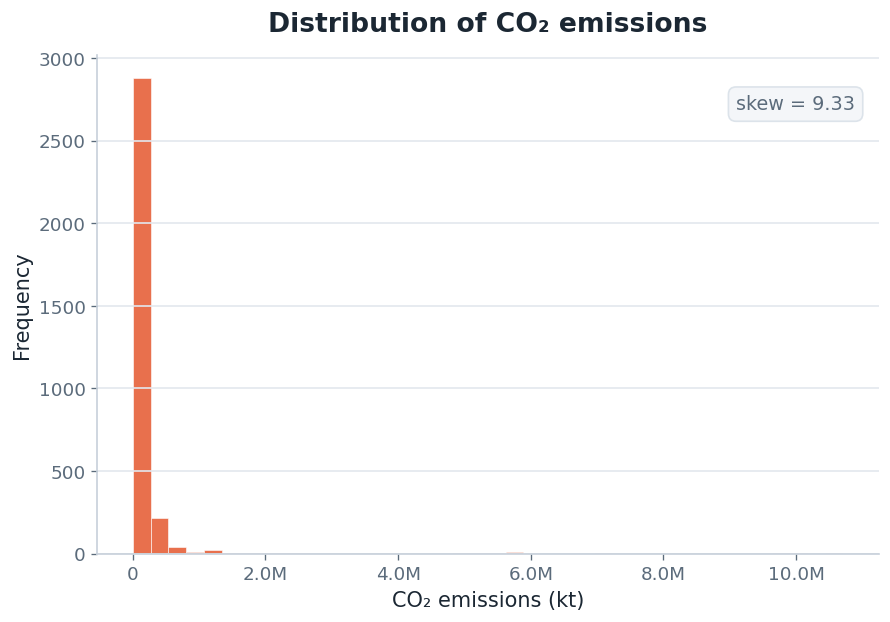

  saved: images/01_dist_co2.png


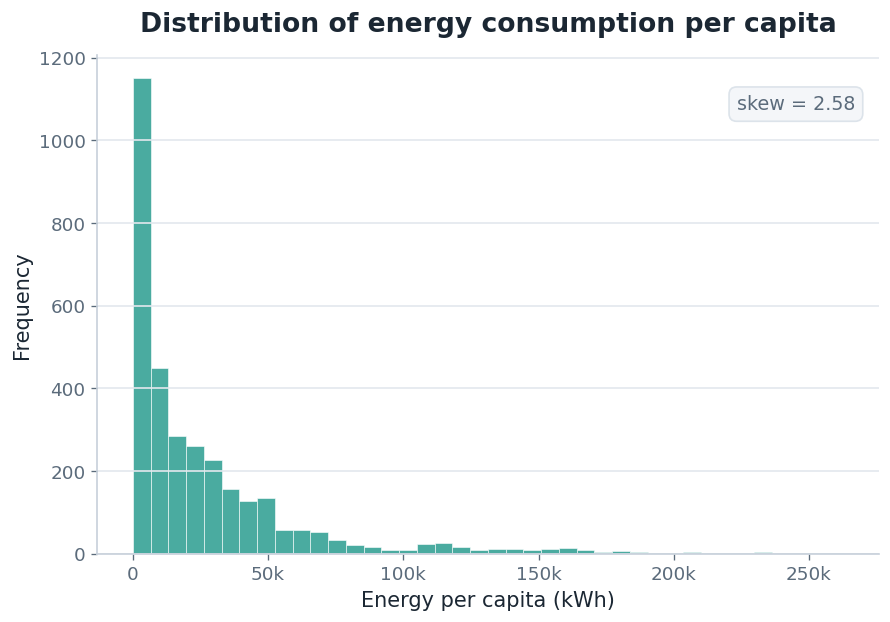

  saved: images/02_dist_energy.png


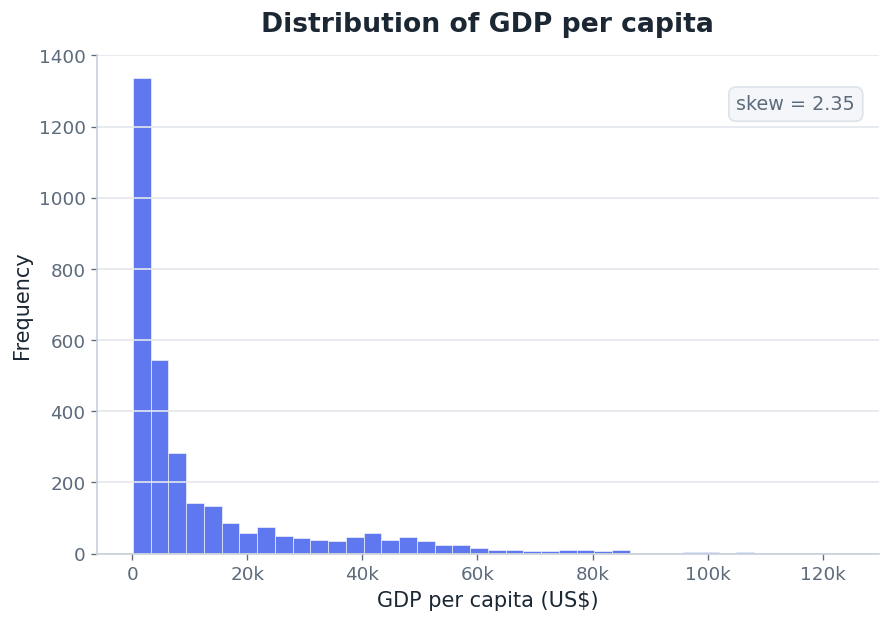

  saved: images/03_dist_gdp.png


In [3]:
hist(df, "Value_co2_emissions_kt_by_country", C_CO2,
     "Distribution of CO\u2082 emissions", "CO\u2082 emissions (kt)", "01_dist_co2.png")
hist(df, "Primary energy consumption per capita (kWh/person)", C_ENERGY,
     "Distribution of energy consumption per capita", "Energy per capita (kWh)", "02_dist_energy.png")
hist(df, "gdp_per_capita", C_GDP,
     "Distribution of GDP per capita", "GDP per capita (US$)", "03_dist_gdp.png")

### 3.2 Outliers (boxplots)

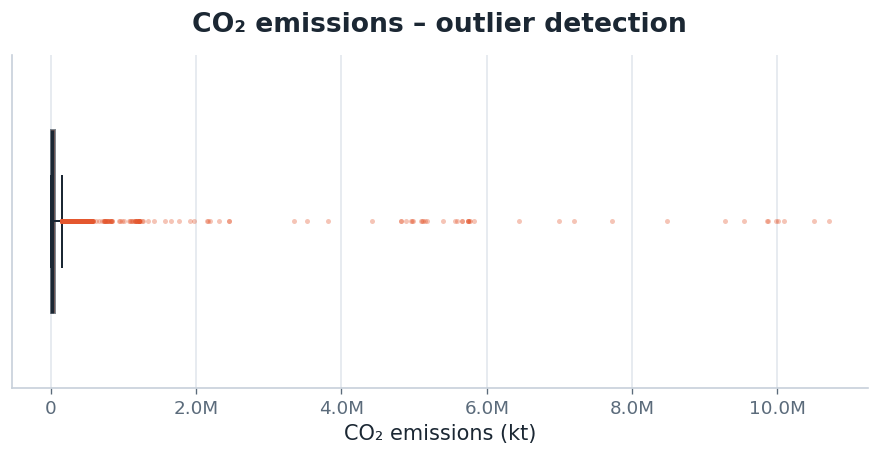

  saved: images/04_box_co2.png


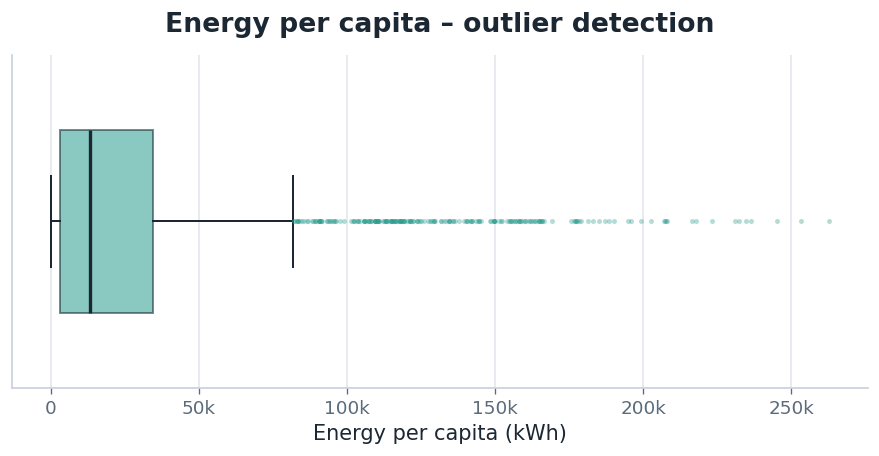

  saved: images/05_box_energy.png


In [4]:
boxplot(df, "Value_co2_emissions_kt_by_country", C_CO2,
        "CO\u2082 emissions \u2013 outlier detection", "CO\u2082 emissions (kt)", "04_box_co2.png")
boxplot(df, "Primary energy consumption per capita (kWh/person)", C_ENERGY,
        "Energy per capita \u2013 outlier detection", "Energy per capita (kWh)", "05_box_energy.png")

### 3.3 Correlation matrix

CO\u2082 emissions are almost perfectly correlated with fossil-fuel electricity.

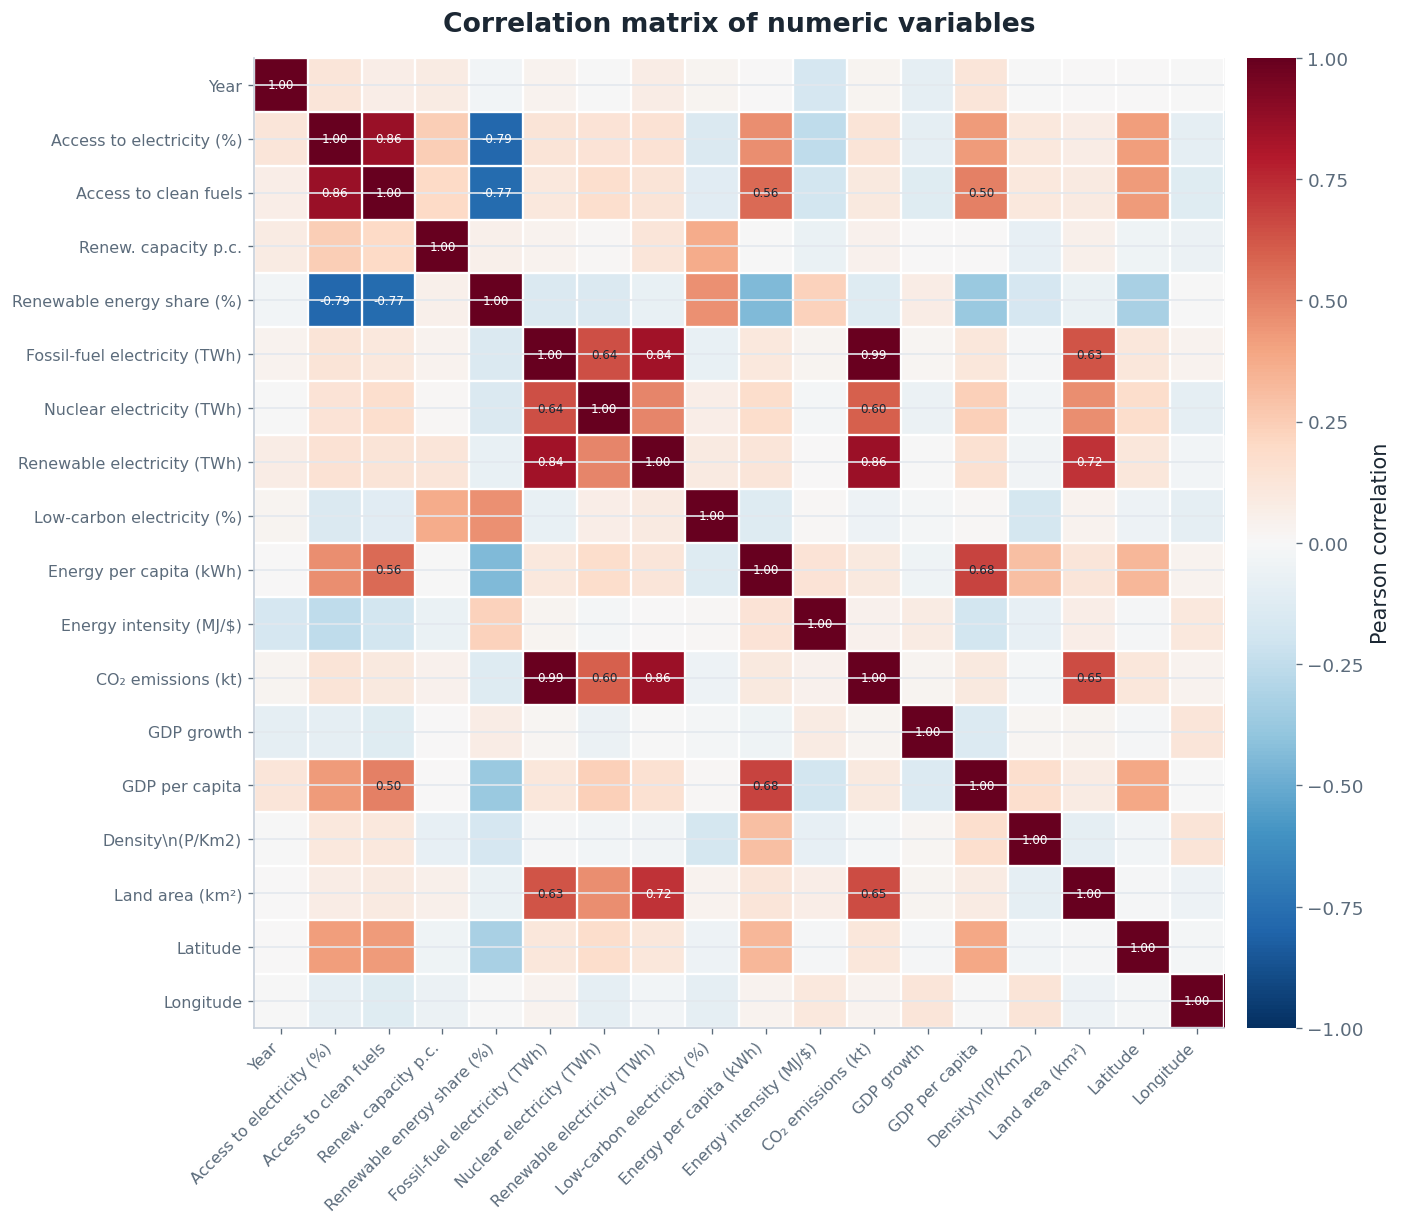

  saved: images/06_correlation_matrix.png


In [5]:
correlation_heatmap(df, "06_correlation_matrix.png")

### 3.4 Temporal trends

Global emissions keep rising after the 2015 Paris Agreement, and the mean
renewable share stays almost flat.

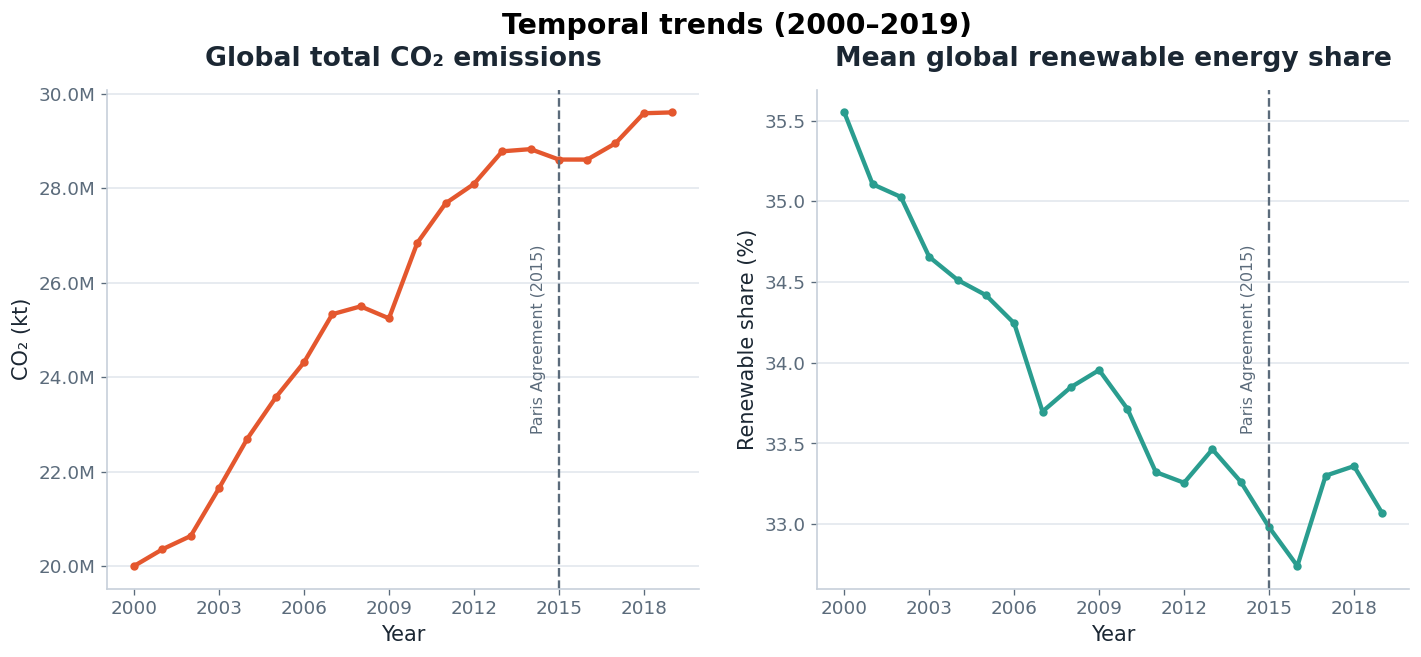

  saved: images/07_temporal_trends.png


In [6]:
temporal(df, "07_temporal_trends.png")

## 4. Model A — CO₂ emissions (without fossil-fuel electricity)

Fossil-fuel electricity is so correlated with emissions that a model keeping it is
almost trivial and hides every other variable. Model A is therefore trained
without it, using the structural variables of the energy system. Temporal split:
train on 2000–2015, test on 2016–2019.

Dropping the fossil variable lowers the scores, as expected, and Ridge becomes the
best model. Renewable generation turns into the main predictor.

In [7]:
features_co2 = ["Year",
    "Electricity from nuclear (TWh)", "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)"]

res_co2 = train_models(df, features_co2, "Value_co2_emissions_kt_by_country")

for name in ["Linear Regression", "Ridge Regression", "Random Forest"]:
    r = res_co2[name]
    print(f"{name:20s}  R2={r['r2']:.4f}  RMSE={r['rmse']:,.0f} kt")

Linear Regression     R2=0.8048  RMSE=405,271 kt
Ridge Regression      R2=0.9086  RMSE=277,366 kt
Random Forest         R2=0.8756  RMSE=323,585 kt


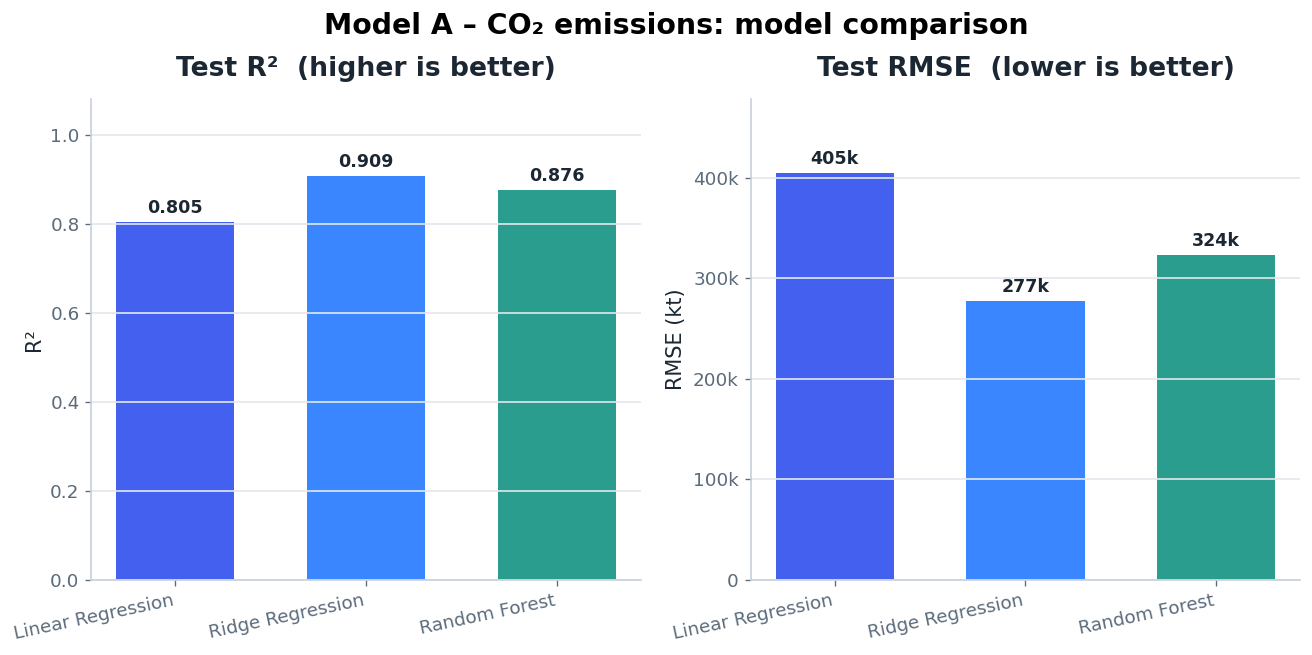

  saved: images/08_modelA_co2_comparison.png


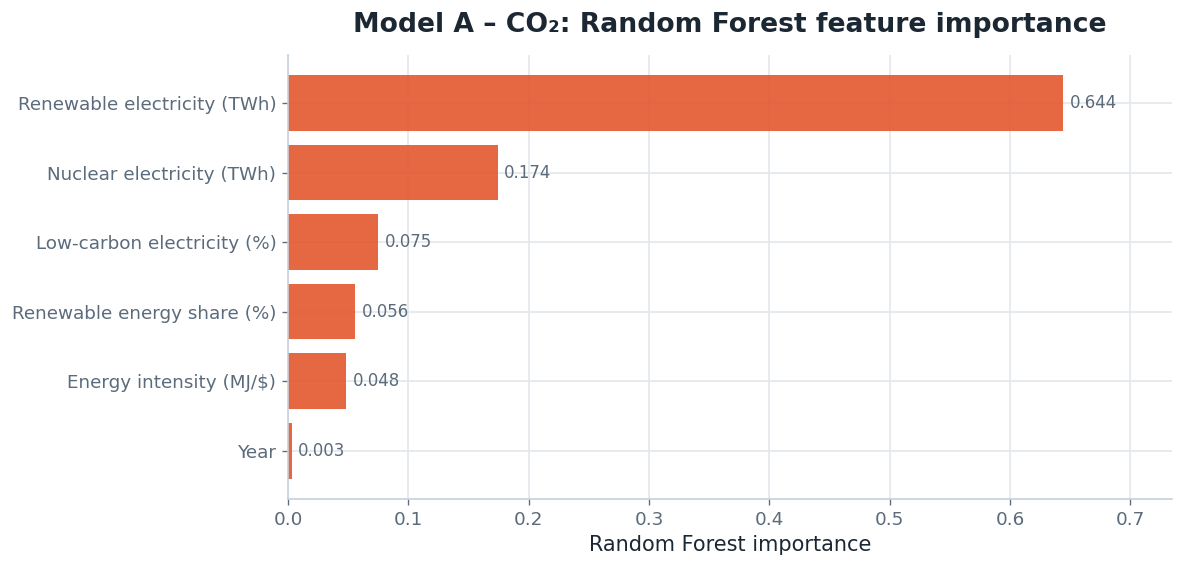

  saved: images/09_modelA_co2_importance.png


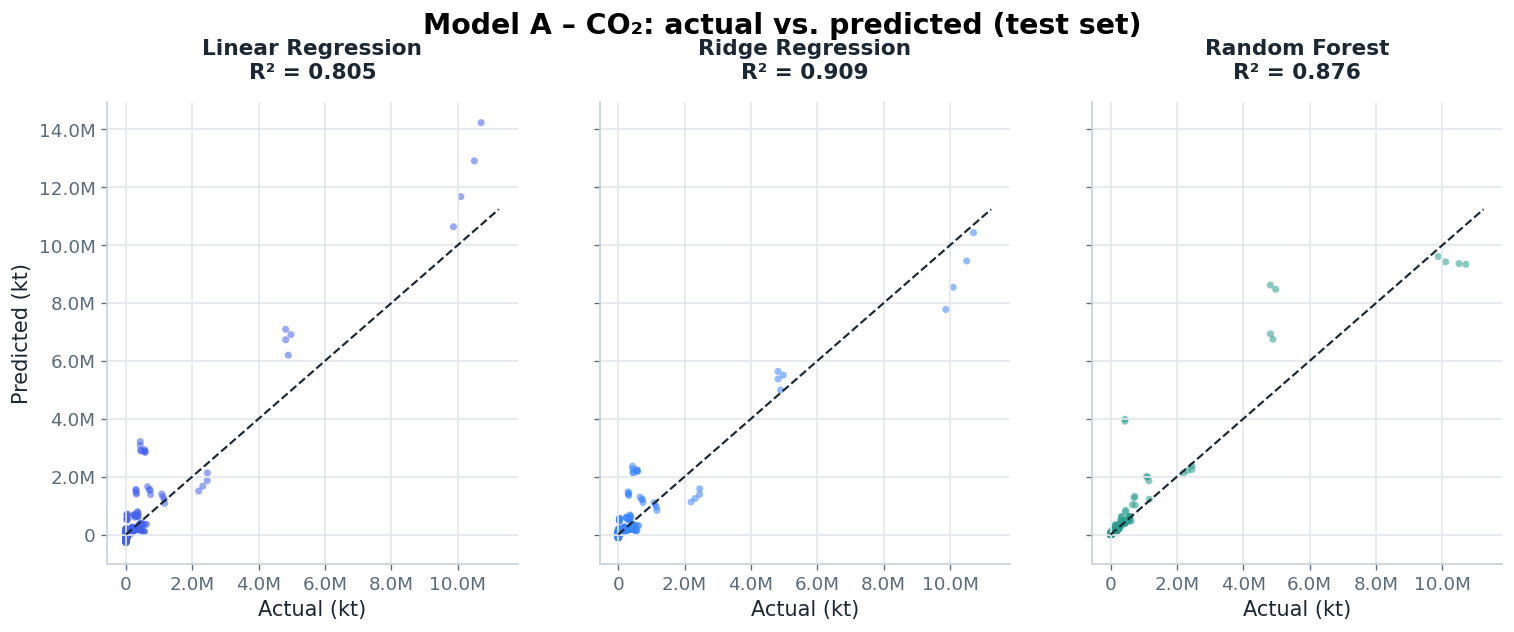

  saved: images/10_modelA_co2_actual_vs_pred.png


In [8]:
model_comparison(res_co2, "Model A \u2013 CO\u2082 emissions: model comparison", "kt", "08_modelA_co2_comparison.png")
feature_importance(res_co2, "Model A \u2013 CO\u2082: Random Forest feature importance", "09_modelA_co2_importance.png", C_CO2)
actual_vs_predicted(res_co2, "Model A \u2013 CO\u2082: actual vs. predicted (test set)", "kt", "10_modelA_co2_actual_vs_pred.png")

## 5. Model B — Energy consumption per capita

This model adds the economic variables (GDP per capita, energy intensity, country
size). The relationship is clearly non-linear, and Random Forest is much better
than the linear models.

In [9]:
features_energy = ["gdp_per_capita", "gdp_growth",
    "Electricity from fossil fuels (TWh)", "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "Access to electricity (% of population)", "Land Area(Km2)"]

res_en = train_models(df, features_energy, "Primary energy consumption per capita (kWh/person)")

for name in ["Linear Regression", "Ridge Regression", "Random Forest"]:
    r = res_en[name]
    print(f"{name:20s}  R2={r['r2']:.4f}  RMSE={r['rmse']:,.0f} kWh")

Linear Regression     R2=0.6350  RMSE=21,441 kWh
Ridge Regression      R2=0.6313  RMSE=21,550 kWh
Random Forest         R2=0.9635  RMSE=6,777 kWh


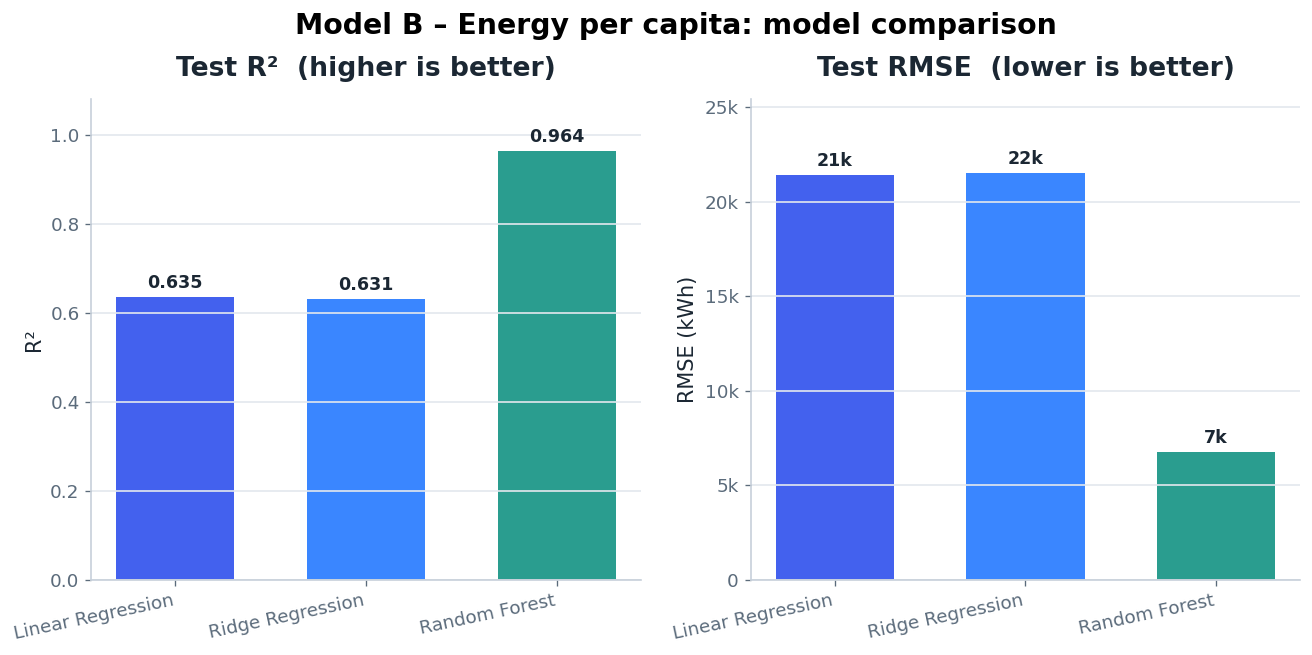

  saved: images/11_modelB_energy_comparison.png


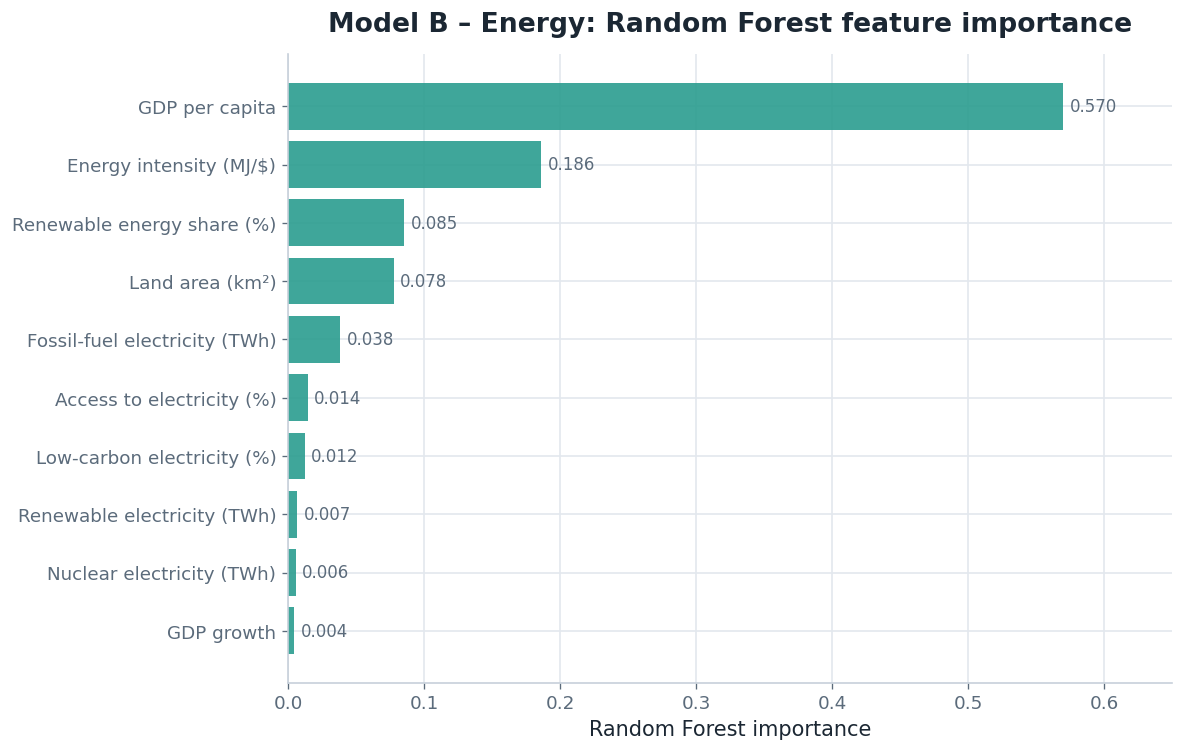

  saved: images/12_modelB_energy_importance.png


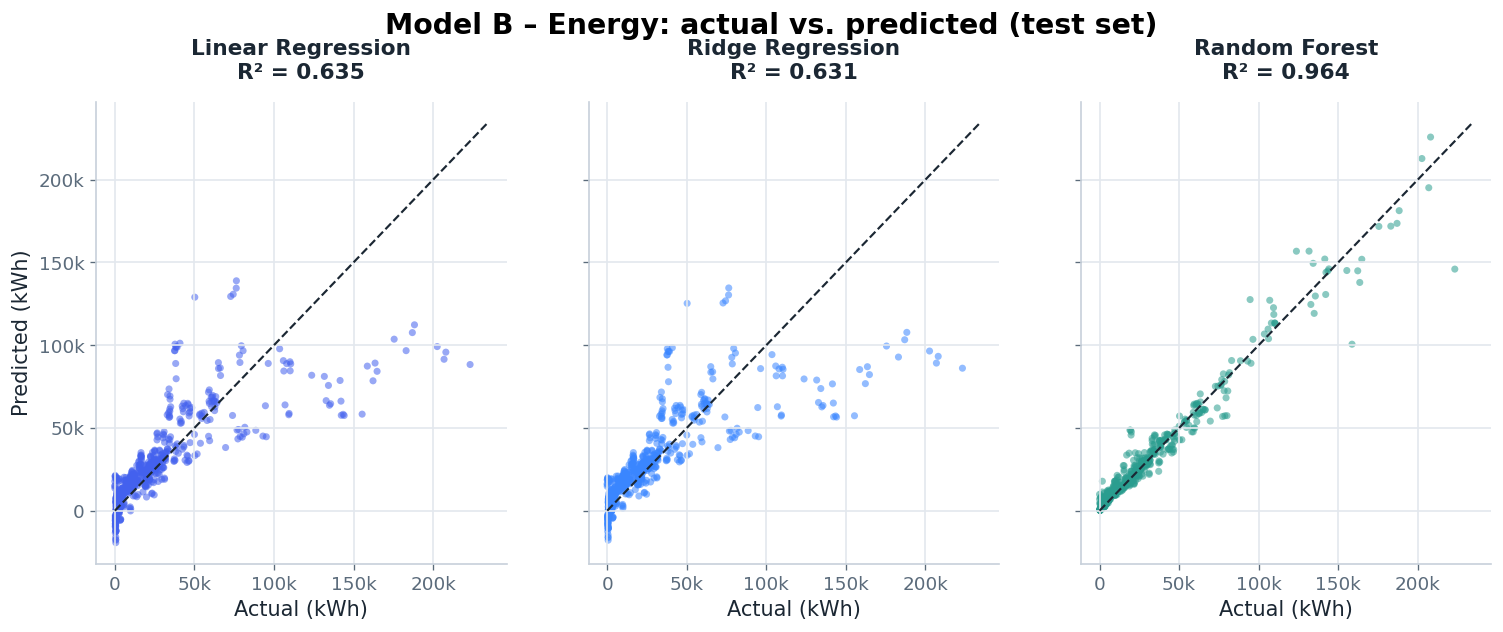

  saved: images/13_modelB_energy_actual_vs_pred.png


In [10]:
model_comparison(res_en, "Model B \u2013 Energy per capita: model comparison", "kWh", "11_modelB_energy_comparison.png")
feature_importance(res_en, "Model B \u2013 Energy: Random Forest feature importance", "12_modelB_energy_importance.png", C_ENERGY)
actual_vs_predicted(res_en, "Model B \u2013 Energy: actual vs. predicted (test set)", "kWh", "13_modelB_energy_actual_vs_pred.png")